imports and load dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
fraud = pd.read_csv('../data/raw/Fraud_Data.csv')
ip_country = pd.read_csv('../data/raw/IpAddress_to_Country.csv')
fraud.head()

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0


data types and shapes

In [2]:
print(fraud.shape)
print(fraud.dtypes)

(151112, 11)
user_id             int64
signup_time           str
purchase_time         str
purchase_value      int64
device_id             str
source                str
browser               str
sex                   str
age                 int64
ip_address        float64
class               int64
dtype: object


missing values and duplicates

In [3]:
fraud.isnull().sum()
print("Duplicate rows:", fraud.duplicated().sum())


Duplicate rows: 0


class imbalance 
class distribution

class
0    136961
1     14151
Name: count, dtype: int64
class
0    90.64
1     9.36
Name: proportion, dtype: float64


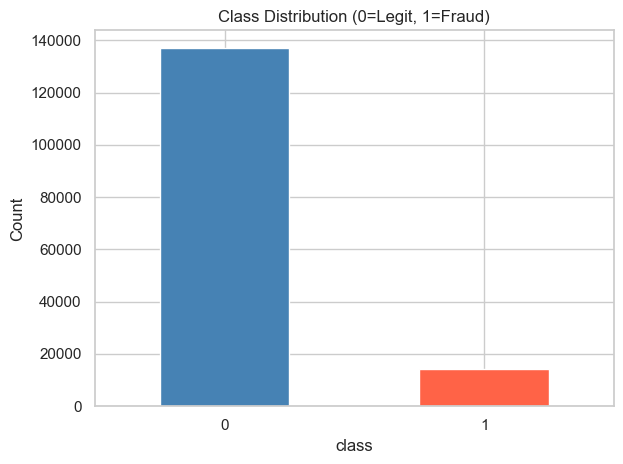

In [4]:
counts = fraud['class'].value_counts()
pct = fraud['class'].value_counts(normalize=True) * 100

print(counts)
print(pct.round(2))

counts.plot(kind='bar', color=['steelblue','tomato'])
plt.title('Class Distribution (0=Legit, 1=Fraud)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

 Univariate Distributions
numerical distributions

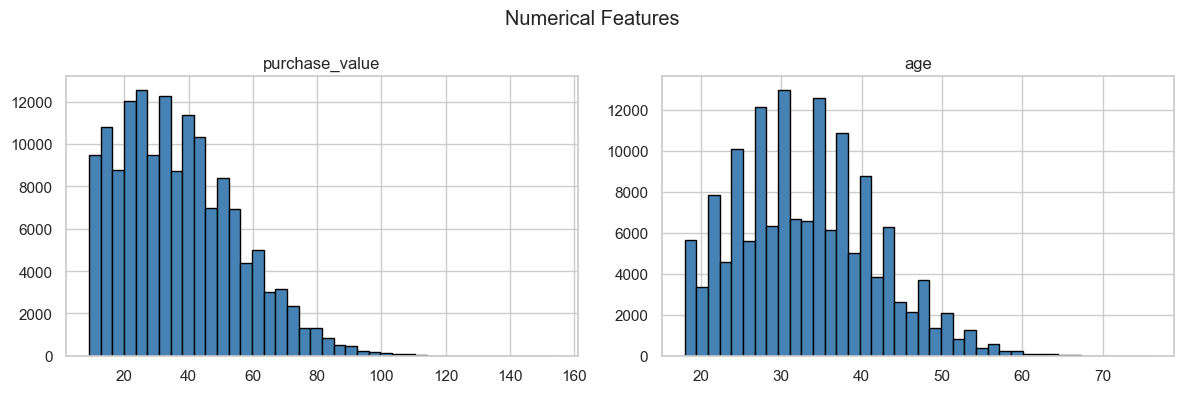

In [5]:
fraud[['purchase_value', 'age']].hist(bins=40, figsize=(12, 4), color='steelblue', edgecolor='black')
plt.suptitle('Numerical Features')
plt.tight_layout()
plt.show()

categorical value points

In [6]:
for col in ['source', 'browser', 'sex']:
    print(fraud[col].value_counts(), '\n')

source
SEO       60615
Ads       59881
Direct    30616
Name: count, dtype: int64 

browser
Chrome     61432
IE         36727
Safari     24667
FireFox    24610
Opera       3676
Name: count, dtype: int64 

sex
M    88293
F    62819
Name: count, dtype: int64 



Bivariate: Feature vs Fraud
purchase value by class

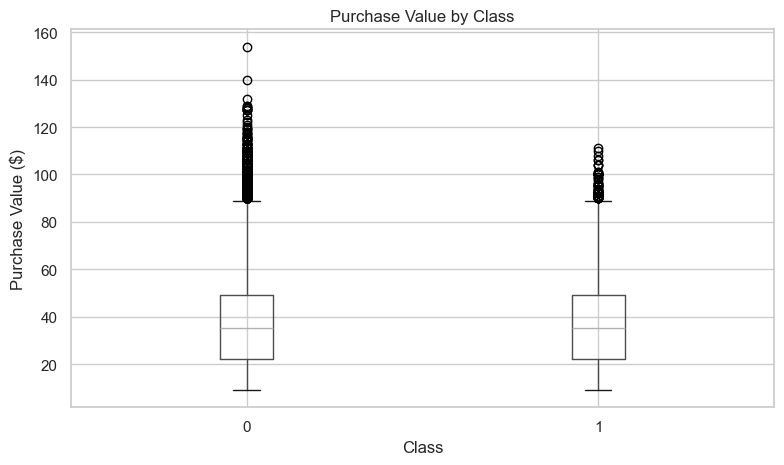

In [7]:
fraud.boxplot(column='purchase_value', by='class', figsize=(8, 5))
plt.title('Purchase Value by Class')
plt.suptitle('')
plt.xlabel('Class')
plt.ylabel('Purchase Value ($)')
plt.tight_layout()
plt.show()

age by class

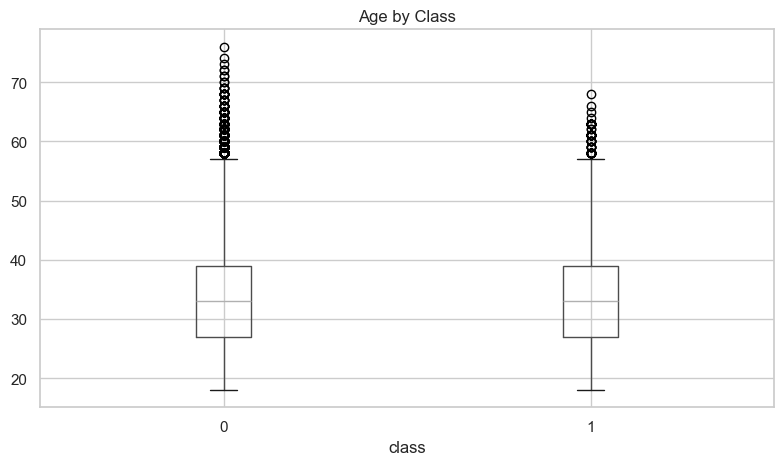

In [8]:
fraud.boxplot(column='age', by='class', figsize=(8, 5))
plt.title('Age by Class')
plt.suptitle('')
plt.tight_layout()
plt.show()

 Fraud rate by categorical columns

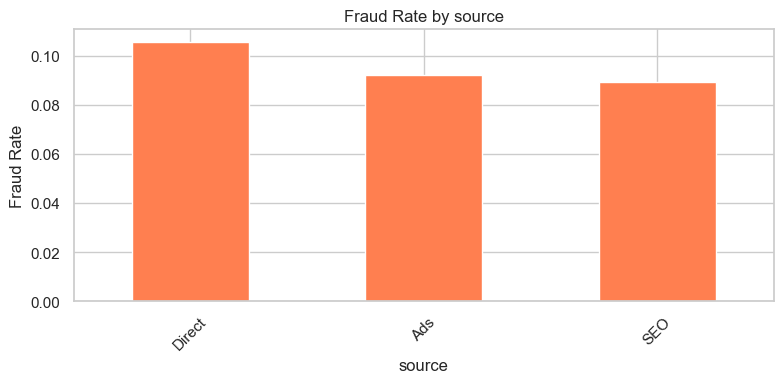

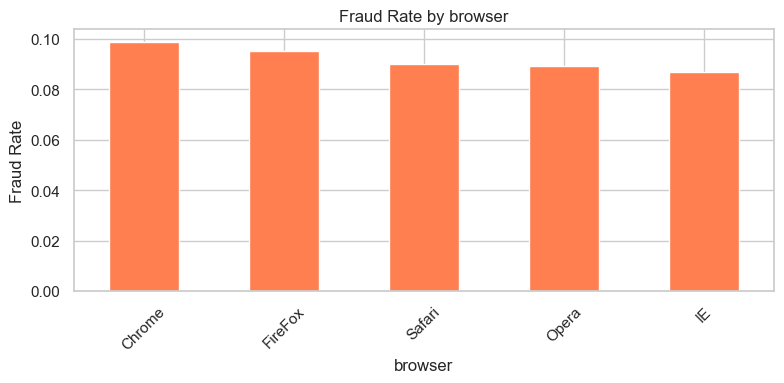

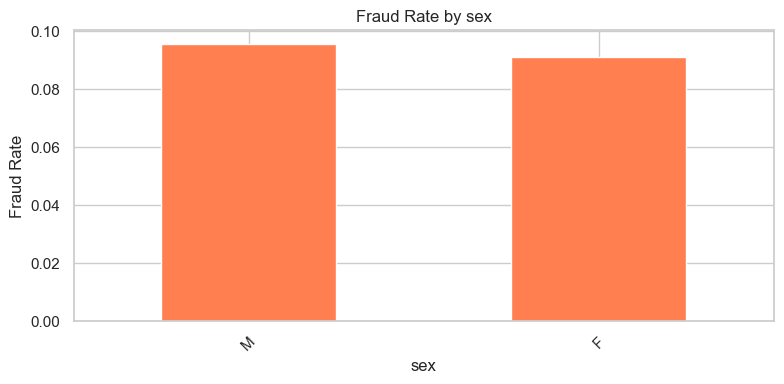

In [9]:
for col in ['source', 'browser', 'sex']:
    rate = fraud.groupby(col)['class'].mean().sort_values(ascending=False)
    rate.plot(kind='bar', title=f'Fraud Rate by {col}', figsize=(8, 4), color='coral')
    plt.ylabel('Fraud Rate')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()